# Compare market production methods (savegame)

Loads **format-2** `.pkl` snapshots from `analysis/savegame/notebooks/save_game_temp` (same pipeline as `compare_savegames_market.ipynb`): `locations` (already merged with region hierarchy), `buildings` (production methods per building), `market_goods`, etc.

**Recipe weights and PM slot groups** (food / drinks / packaging) are loaded from **`game_path` / `mod_path`** in your config via `BuildingData`—the same definitions as `production_method_comparison.ipynb`. Snapshots only store *which* PM each building uses; they do not embed recipe quantities.

Filters to one building type (default **`cookery`**, e.g. Prosper or Perish). Use `first_savegame` / `last_savegame` to slice snapshots (`last_savegame = 1` with `first_savegame = 0` for a single file).

**Global resource usage:** for the **latest** snapshot, three tables (**food** / **drinks** / **packaging**) list each trade **good** and **total_input** = sum over all cookery buildings of (recipe input parsed from `building_types` × buildings using that PM). PMs with no goods (e.g. well water, no packaging) contribute no rows. Locations are merged with **`LocationData`** (`merge_saves_with_location_data`) so **`macro_region`** is available; one column per macro region (slug as column name, same units as `total_input`), ordered by **descending column total** within that category so the largest regional footprints appear first. Missing macro region is bucketed as **`__unknown`**. Each table also includes **base_cost** (game `default_market_price` from merged goods definitions) and **total_cost** = `total_input` × `base_cost`.

**Global PM table:** counts how many cookery buildings use each `pp_cookery_*` method in the **latest** loaded snapshot (so totals are not multiplied when you load many time slices). Rows are grouped into **food**, **drinks**, and **packaging** to match the three `unique_production_methods` slots in the Prosper or Perish cookery building.

**Regional PM preferences:** three wide tables (`regional_prefs_food` / `regional_prefs_drinks` / `regional_prefs_packaging`) give, for each **macro region**, the **percentage share** of each production method in that slot as **whole-number** percentages (rows sum to ~100% per region); column names drop the `pp_cookery_` prefix for readability. PM columns are ordered by global usage in that slot (most common first).

**Regional spend mix:** three wide tables (`regional_spend_share_food` / `regional_spend_share_drinks` / `regional_spend_share_packaging`) show, for each **macro region**, the **percentage** of **base-price** cookery input spend (recipe quantity × `default_market_price` per trade good) allocated to each **good** in that slot; rows match regional PM ordering, good columns by descending global spend in that slot.

**Time-series plots:** when you load **multiple** snapshots, three line charts show how many buildings globally use each production method in the food, drink, and packaging slots over time (one line per `pp_cookery_*` method in that slot). The horizontal axis matches **`compare_savegames.ipynb`**: snapshot index 0, 1, … is labeled as **game years** (`start_year` 1337 + index × `years_per_snapshot` 5).

Pkls must include a **`buildings`** key (re-run the savegame watcher / processor with current ProsperPerishCalcs if yours were produced before that field existed).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display

from core.parser.path_resolver import PathResolver
from core.data.building_data import BuildingData
from core.data.goods_data import GoodsData
from analysis.building_levels.building_analysis import load_config
from analysis.savegame import (
    buildings_df_from_pkl,
    locations_df_from_pkl,
    resolve_pkl_dir,
)
from analysis.savegame.datalocations import merge_saves_with_location_data

pd.options.display.max_columns = None
pd.options.display.width = 200

In [2]:
# Cookery: three UPM slots from parsed mod `building_types` (same source as production_method_comparison)
config = load_config()
path_resolver = PathResolver(config["game_path"], config["mod_path"])
building_data = BuildingData(path_resolver)
building_data.load_all()

goods_data = GoodsData(path_resolver)
goods_data.load_all()

cookery_maps = building_data.cookery_pm_maps("cookery")

_COOKERY_PM_FOOD = cookery_maps.food
_COOKERY_PM_DRINKS = cookery_maps.drinks
_COOKERY_PM_PACKAGING = cookery_maps.packaging
_COOKERY_PM_GOOD_INPUTS = cookery_maps.pm_good_inputs


def _cookery_pm_category(pm: str) -> str:
    return cookery_maps.category(pm)


In [3]:
"""Load .pkl snapshots (format-2 with market_goods + buildings)."""

# None = auto (newest playthrough under save_game_temp), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0
last_savegame = None  # None = all; use 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    if "buildings" not in payload:
        raise ValueError(
            f"{label}: pkl has no 'buildings' key. Regenerate snapshots with the current "
            "savegame processor / watcher (format-2 now includes buildings)."
        )

_locations_merged = merge_saves_with_location_data(raw)

n_snap = len(raw)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(raw.keys())}")

Loaded 35 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\921644ba_e9b7_48f9_9144_2c0874e357c1
Labels: ['20260323_164549', '20260323_164718', '20260323_164848', '20260323_165022', '20260323_165147', '20260323_165318', '20260323_165450', '20260323_165624', '20260323_165802', '20260323_170002', '20260323_170121', '20260323_170244', '20260323_170404', '20260323_170527', '20260323_170649', '20260323_170811', '20260323_171106', '20260323_171347', '20260323_171528', '20260323_171651', '20260323_171814', '20260323_171940', '20260323_172103', '20260323_172227', '20260323_172352', '20260323_172513', '20260323_172635', '20260323_172803', '20260323_172923', '20260323_173043', '20260323_173204', '20260323_173323', '20260323_173446', '20260323_173613', '20260323_173735']


In [4]:
# Building type to analyze (Prosper or Perish cookery); set to None to include all building types
BUILDING_SLUG = "cookery"

parts = []
for label, payload in raw.items():
    b = buildings_df_from_pkl(payload)
    if BUILDING_SLUG and "slug" in b.columns:
        b = b[b["slug"] == BUILDING_SLUG].copy()
    b["snapshot"] = label
    loc = _locations_merged.get(label)
    if not isinstance(loc, pd.DataFrame) or "location_id" not in loc.columns:
        loc = locations_df_from_pkl(payload)
    if "macro_region" not in loc.columns:
        for alias in ("macro_region_loc", "macro_region_pkl"):
            if alias in loc.columns:
                loc = loc.copy()
                loc["macro_region"] = loc[alias]
                break
    scope = [c for c in ("region", "macro_region", "super_region") if c in loc.columns]
    if "location_id" not in loc.columns or not scope:
        raise ValueError(f"{label}: locations frame missing location_id or scope columns.")
    # Omit location `slug` so it does not collide with building `slug`
    loc_sub = loc[["location_id", *scope]].drop_duplicates(subset=["location_id"])
    merged = b.merge(loc_sub, on="location_id", how="left", suffixes=("", "_loc"))
    parts.append(merged)

enriched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
# if not enriched.empty:
#     display(enriched.head(20))
# else:
#     slug_msg = f"slug={BUILDING_SLUG!r}" if BUILDING_SLUG else "all slugs"
#     print(f"No matching buildings ({slug_msg}) in selected snapshot(s).")

In [5]:
# Global PM table (latest snapshot only)
if enriched.empty:
    pm_global = pd.DataFrame()
    print("No data for global PM counts.")
else:
    # Latest snapshot only: one world state, not N × duplicate buildings across time slices
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global PM counts use snapshot: {_last_snap}")
    else:
        _base = enriched

    pm_long = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_long = pm_long[pm_long["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    counts = pm_long["production_method"].value_counts()
    pm_global = counts.rename("building_uses").reset_index()
    pm_global.columns = ["production_method", "building_uses"]
    pm_global["category"] = pm_global["production_method"].map(_cookery_pm_category)
    _cat_order = {"food": 0, "drinks": 1, "packaging": 2, "other": 3}
    pm_global["_k"] = pm_global["category"].map(_cat_order)
    pm_global = (
        pm_global.sort_values(["_k", "building_uses", "production_method"], ascending=[True, False, True])
        .drop(columns=["_k"])
        .reset_index(drop=True)
    )
    display(pm_global)
    cat_totals = (
        pm_global.groupby("category", sort=False)["building_uses"]
        .sum()
        .reindex(["food", "drinks", "packaging", "other"], fill_value=0)
        .rename("sum_building_uses")
        .to_frame()
    )
    display(cat_totals)

Global PM counts use snapshot: 20260323_173735


,production_method,building_uses,category
0,pp_cookery_livestock_pottage,491,food
1,pp_cookery_mutton_and_pease,321,food
2,pp_cookery_fish_congee,245,food
3,pp_cookery_pemmican,245,food
4,pp_cookery_meat_tajine,186,food
5,pp_cookery_ika_mata,158,food
6,pp_cookery_khichdi,144,food
7,pp_cookery_saltfish_porridge,116,food
8,pp_cookery_kheer,86,food
9,pp_cookery_mediterranean_fish,78,food


,sum_building_uses
category,
food,2248
drinks,2248
packaging,2248
other,0


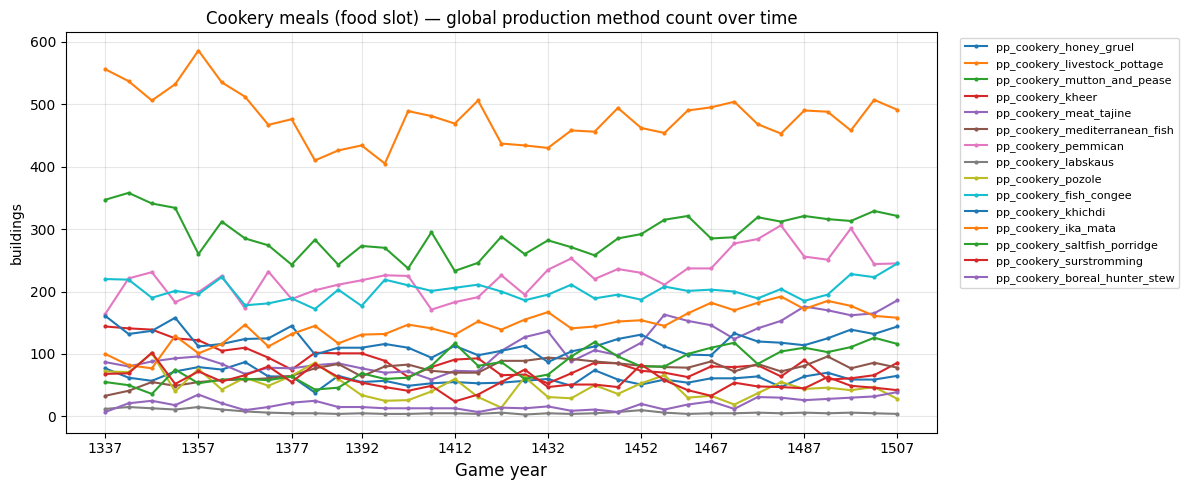

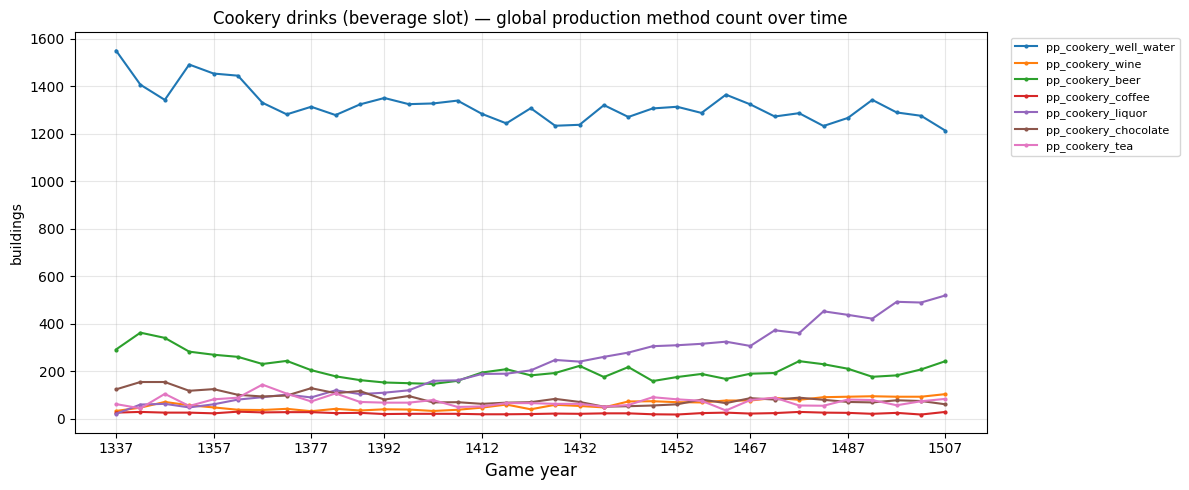

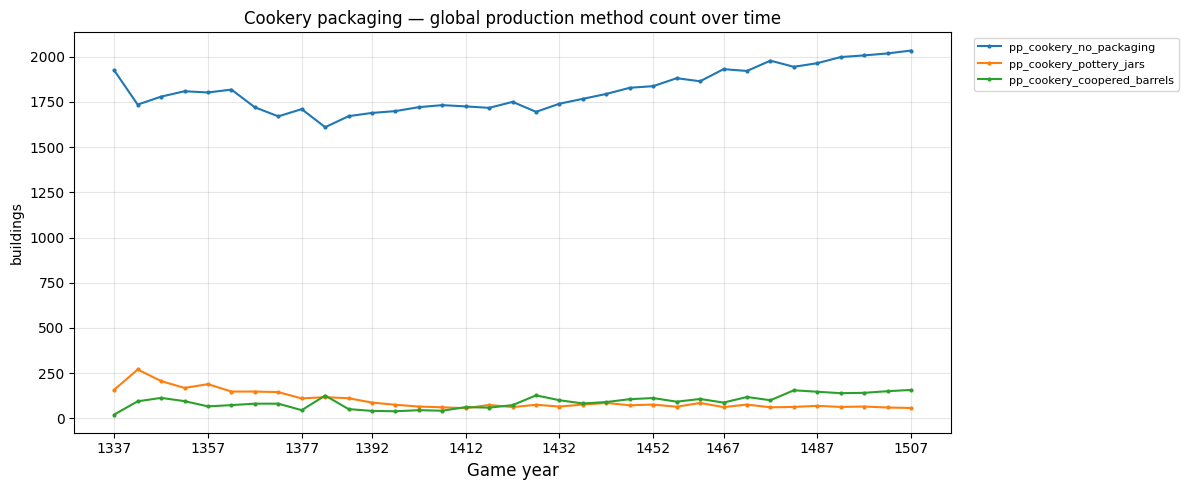

In [6]:
# Time series: global cookery PM counts per snapshot (meals / drinks / packaging slots)
if enriched.empty or "snapshot" not in enriched.columns:
    print("No time-series data (need non-empty enriched with snapshot).")
else:
    pm_ts = enriched.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_ts = pm_ts[pm_ts["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    pm_ts["category"] = pm_ts["production_method"].map(_cookery_pm_category)
    pm_ts = pm_ts[pm_ts["category"] != "other"]
    if pm_ts.empty:
        print("No pp_cookery_* production methods to plot.")
    else:
        counts = (
            pm_ts.groupby(["snapshot", "category", "production_method"], sort=False)
            .size()
            .rename("n")
        )
        snap_order = sorted(enriched["snapshot"].astype(str).unique())
        # X-axis: same convention as compare_savegames.ipynb (snapshot index -> game year)
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_ticks = 10
        n = len(snap_order)
        x_pos = list(range(n))
        if n <= 1:
            tick_positions = list(range(n))
        elif n <= n_ticks:
            tick_positions = list(range(n))
        else:
            step = (n - 1) / (n_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]

        _slot_titles = {
            "food": "Cookery meals (food slot) — global production method count over time",
            "drinks": "Cookery drinks (beverage slot) — global production method count over time",
            "packaging": "Cookery packaging — global production method count over time",
        }
        for cat in ("food", "drinks", "packaging"):
            try:
                sub = counts.xs(cat, level="category")
            except KeyError:
                print(f"Skip time-series plot: no rows for category {cat!r}.")
                continue
            wide = sub.unstack(level="production_method", fill_value=0)
            wide = wide.reindex(snap_order).fillna(0).astype(int)
            if wide.empty:
                print(f"Skip time-series plot: empty pivot for {cat!r}.")
                continue
            fig, ax = plt.subplots(figsize=(12, 5))
            for col in wide.columns:
                ax.plot(x_pos, wide[col].values, label=col, marker="o", markersize=2)
            ax.set_title(_slot_titles[cat])
            ax.set_ylabel("buildings")
            ax.set_xlabel("Game year", fontsize=12)
            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, axis="both", alpha=0.3, linestyle="-")
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
            fig.tight_layout()
            plt.show()

In [7]:
# Global trade-good input usage (latest snapshot), by slot category — recipe inputs from
# Parsed per-PM trade-good inputs (_COOKERY_PM_GOOD_INPUTS) × count of cookery buildings using each PM.
if enriched.empty:
    print("No data for global resource usage.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global resource usage — snapshot {_last_snap}")
    else:
        _base = enriched
    ex = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex = ex[ex["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if ex.empty:
        print("No pp_cookery_* production methods in this slice.")
    else:
        def _mr_col_suffix(mr):
            if pd.isna(mr):
                return "__unknown"
            return str(mr).strip().replace(" ", "_")

        pm_counts = ex["production_method"].value_counts()
        if "macro_region" in ex.columns:
            _mr_levels = sorted(
                {_mr_col_suffix(mr) for mr, _ in ex.groupby("macro_region", dropna=False)}
            )
        else:
            _mr_levels = []
            print(
                "No macro_region on building rows; omitting per-macro_region columns "
                "(use merged locations / pkls with hierarchy)."
            )
        for cat in ("food", "drinks", "packaging"):
            totals = defaultdict(float)
            for pm, n in pm_counts.items():
                if _cookery_pm_category(pm) != cat:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    totals[good] += float(n) * float(qty)
            if not totals:
                print(f"\n{cat}: no trade-good inputs (empty recipe or no buildings).")
                continue
            totals_reg = defaultdict(lambda: defaultdict(float))
            if _mr_levels:
                for mr, ex_mr in ex.groupby("macro_region", dropna=False):
                    mk = _mr_col_suffix(mr)
                    pm_counts_mr = ex_mr["production_method"].value_counts()
                    for pm, n in pm_counts_mr.items():
                        if _cookery_pm_category(pm) != cat:
                            continue
                        for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                            totals_reg[good][mk] += float(n) * float(qty)
            df = pd.DataFrame(
                sorted(totals.items(), key=lambda kv: -kv[1]),
                columns=["good", "total_input"],
            )
            df["total_input"] = df["total_input"].round(2)
            df.insert(0, "category", cat)
            if _mr_levels:
                mr_cols = list(_mr_levels)
                for mrk in mr_cols:
                    df[mrk] = [
                        round(totals_reg[g].get(mrk, 0.0), 2) for g in df["good"]
                    ]
                _mr_order = df[mr_cols].sum().sort_values(ascending=False).index.tolist()
                df = df[["category", "good", "total_input", *_mr_order]]
            df["base_cost"] = df["good"].map(goods_data.modded_df["default_market_price"])
            df["total_cost"] = (df["total_input"] * df["base_cost"]).round(2)
            if _mr_levels:
                df = df[["category", "good", "total_input", "total_cost", "base_cost", *_mr_order]]
            else:
                df = df[["category", "good", "total_input", "total_cost", "base_cost"]]
            _missing = df.loc[df["base_cost"].isna(), "good"].tolist()
            if _missing:
                print(f"  Warning: no default_market_price in merged goods for: {_missing}")
            print(f"\n--- {cat} ---")
            display(df)

Global resource usage — snapshot 20260323_173735

--- food ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_east_asia,south_asia,middle_east,north_america,east_africa,west_africa,north_africa,central_asia,south_america,southern_africa,central_africa,pacific_islands,north_asia
0,food,fish,2346.85,2346.85,1.00,679.41,389.26,178.70,459.73,198.56,104.29,36.00,86.94,79.12,98.55,0.00,26.00,7.48,0.00,2.81,0.0
1,food,livestock,2177.36,3266.04,1.50,838.30,348.02,313.02,33.64,137.56,235.00,23.50,77.52,73.62,43.50,38.98,11.96,1.80,0.94,0.00,0.0
2,food,wheat,1727.20,1727.20,1.00,743.20,211.20,333.60,13.60,69.60,171.20,0.00,69.60,44.80,43.20,27.20,0.00,0.00,0.00,0.00,0.0
3,food,rice,1567.50,1567.50,1.00,102.30,689.70,3.30,349.80,267.30,62.70,6.60,16.50,56.10,6.60,0.00,0.00,3.30,0.00,3.30,0.0
4,food,legumes,1263.07,1263.07,1.00,426.01,315.05,141.63,73.72,95.33,98.30,49.30,17.32,17.53,19.29,9.59,0.00,0.00,0.00,0.00,0.0
5,food,wild_game,1175.30,1175.30,1.00,337.50,306.00,148.50,27.00,85.50,45.00,180.10,13.50,13.50,0.00,9.00,5.20,0.00,4.50,0.00,0.0
6,food,wool,1139.55,1424.44,1.25,525.40,92.30,163.30,46.15,63.90,117.15,92.30,0.00,0.00,28.40,10.65,0.00,0.00,0.00,0.00,0.0
7,food,fruit,1040.95,1040.95,1.00,304.25,164.86,85.63,120.77,78.85,104.82,47.50,42.85,24.00,39.14,14.78,12.50,0.00,1.00,0.00,0.0
8,food,millet,399.34,399.34,1.00,188.01,24.01,74.27,22.90,26.00,5.20,0.00,23.15,26.00,2.60,0.00,0.00,5.20,0.00,0.00,2.0
9,food,salt,130.74,653.70,5.00,58.81,10.51,16.37,13.10,7.10,7.60,6.10,4.65,2.20,2.60,0.60,0.50,0.40,0.00,0.00,0.2



--- drinks ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,south_asia,south_east_asia,eastern_europe,middle_east,north_america,east_africa,west_africa,north_africa,central_asia,south_america,central_africa,pacific_islands,north_asia,southern_africa
0,drinks,liquor,856.35,2140.88,2.5,415.8,148.50,84.15,80.85,36.3,47.85,1.65,9.9,14.85,9.90,6.6,0.00,0.0,0.0,0.0,0.0
1,drinks,beer,471.90,943.80,2.0,237.9,60.45,68.25,27.30,42.9,5.85,3.90,0.0,9.75,5.85,7.8,1.95,0.0,0.0,0.0,0.0
2,drinks,wine,216.30,432.60,2.0,119.7,14.70,2.10,16.80,33.6,18.90,0.00,2.1,8.40,0.00,0.0,0.00,0.0,0.0,0.0,0.0
3,drinks,tea,112.05,336.15,3.0,0.0,108.00,0.00,4.05,0.0,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0
4,drinks,cocoa,48.00,192.00,4.0,0.0,0.00,0.00,0.00,0.0,0.00,48.00,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0
5,drinks,coffee,29.40,88.20,3.0,0.0,0.00,0.00,0.00,0.0,4.20,0.00,25.2,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0



--- packaging ---


,category,good,total_input,total_cost,base_cost,western_europe,south_east_asia,east_asia,eastern_europe,middle_east,west_africa,south_asia,north_africa,north_america,south_america,east_africa,central_africa,central_asia,pacific_islands,north_asia,southern_africa
0,packaging,pottery,159.6,159.6,1.0,44.8,22.4,25.2,25.2,11.2,11.2,2.8,8.4,5.6,2.8,0.0,0.0,0.0,0.0,0.0,0.0
1,packaging,furniture,141.3,423.9,3.0,69.3,36.9,21.6,2.7,0.9,0.9,6.3,0.0,1.8,0.0,0.9,0.0,0.0,0.0,0.0,0.0


In [8]:
# Regional PM preferences (latest snapshot): per macro-region % share of each slot's PM assignments.
import numpy as np


def _mr_col_suffix_prefs(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_prefs_food = pd.DataFrame()
regional_prefs_drinks = pd.DataFrame()
regional_prefs_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional PM preferences.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_pref = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_pref = enriched
    ex_pref = _base_pref.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_pref = ex_pref[ex_pref["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_pref.columns:
        print("No macro_region; skipping regional PM preference tables.")
    elif ex_pref.empty:
        print("No pp_cookery_* rows for regional PM preferences.")
    else:
        ex_pref = ex_pref.copy()
        ex_pref["_mr"] = ex_pref["macro_region"].map(_mr_col_suffix_prefs)

        _mr_cookery_order = (
            _base_pref.assign(_mr=_base_pref["macro_region"].map(_mr_col_suffix_prefs))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        def _regional_pm_pct(cat: str, mr_order: list) -> pd.DataFrame:
            sub = ex_pref[ex_pref["production_method"].map(_cookery_pm_category) == cat]
            if sub.empty:
                return pd.DataFrame()
            ct = sub.groupby(["_mr", "production_method"], observed=False).size().unstack(fill_value=0)
            denom = ct.sum(axis=1).replace(0, np.nan)
            pct = (ct.div(denom, axis=0) * 100).fillna(0)
            col_order = ct.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            pct.columns = [str(c).removeprefix("pp_cookery_") for c in pct.columns]
            pct = np.rint(pct).astype(int)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_prefs_food = _regional_pm_pct("food", _mr_cookery_order)
        regional_prefs_drinks = _regional_pm_pct("drinks", _mr_cookery_order)
        regional_prefs_packaging = _regional_pm_pct("packaging", _mr_cookery_order)

        for _slot_name, _sdf in (
            ("food", regional_prefs_food),
            ("drinks", regional_prefs_drinks),
            ("packaging", regional_prefs_packaging),
        ):
            print(f"\n--- {_slot_name} — regional PM % (rows sum to ~100 per macro region) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional PM % (rows sum to ~100 per macro region) ---


,livestock_pottage,mutton_and_pease,fish_congee,pemmican,meat_tajine,ika_mata,khichdi,saltfish_porridge,kheer,mediterranean_fish,honey_gruel,surstromming,boreal_hunter_stew,pozole,labskaus
_mr,,,,,,,,,,,,,,,
western_europe,30,20,1,10,9,5,2,7,1,5,2,3,3,0,0
east_asia,15,6,25,16,7,4,19,0,4,0,1,1,2,0,0
eastern_europe,39,18,0,13,6,3,0,9,0,5,3,0,3,0,0
south_east_asia,1,7,39,3,0,23,9,4,7,0,2,5,0,0,0
south_asia,10,10,21,11,5,9,11,6,15,0,3,0,0,0,0
middle_east,23,19,1,6,18,3,3,1,7,8,10,0,0,0,0
north_america,0,30,0,28,0,10,2,0,0,0,0,0,0,30,0
east_africa,30,0,3,5,15,12,3,13,2,0,8,8,0,0,0
west_africa,25,0,21,5,18,4,5,18,4,0,0,0,0,0,0



--- drinks — regional PM % (rows sum to ~100 per macro region) ---


,well_water,liquor,beer,wine,tea,chocolate,coffee
_mr,,,,,,,
western_europe,41,34,17,8,0,0,0
east_asia,52,21,7,2,19,0,0
eastern_europe,76,9,9,6,0,0,0
south_east_asia,61,26,7,4,2,0,0
south_asia,50,29,20,1,0,0,0
middle_east,74,17,2,5,0,0,2
north_america,28,1,2,0,0,68,0
east_africa,48,10,0,2,0,0,40
west_africa,68,16,9,7,0,0,0



--- packaging — regional PM % (rows sum to ~100 per macro region) ---


,no_packaging,coopered_barrels,pottery_jars
_mr,,,
western_europe,87,11,2
east_asia,92,6,2
eastern_europe,95,1,4
south_east_asia,74,21,4
south_asia,95,4,1
middle_east,97,1,2
north_america,95,2,2
east_africa,98,2,0
west_africa,91,2,7


In [9]:
# Regional spend mix (latest snapshot): % of base-price cookery input spend per trade good, per slot.
import numpy as np
from collections import defaultdict


def _mr_col_suffix_spend(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_spend_share_food = pd.DataFrame()
regional_spend_share_drinks = pd.DataFrame()
regional_spend_share_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional spend mix.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_spend = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_spend = enriched
    ex_s = _base_spend.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_s = ex_s[ex_s["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_s.columns:
        print("No macro_region; skipping regional spend mix tables.")
    elif ex_s.empty:
        print("No pp_cookery_* rows for regional spend mix.")
    else:
        ex_s = ex_s.copy()
        ex_s["_mr"] = ex_s["macro_region"].map(_mr_col_suffix_spend)

        _mr_cookery_order_spend = (
            _base_spend.assign(_mr=_base_spend["macro_region"].map(_mr_col_suffix_spend))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        _price = goods_data.modded_df["default_market_price"]

        spend_food = defaultdict(lambda: defaultdict(float))
        spend_drinks = defaultdict(lambda: defaultdict(float))
        spend_packaging = defaultdict(lambda: defaultdict(float))
        missing_price = set()

        for mr, ex_mr in ex_s.groupby("macro_region", dropna=False):
            mk = _mr_col_suffix_spend(mr)
            pm_counts_mr = ex_mr["production_method"].value_counts()
            for pm, n in pm_counts_mr.items():
                cat = _cookery_pm_category(pm)
                if cat == "food":
                    tgt = spend_food
                elif cat == "drinks":
                    tgt = spend_drinks
                elif cat == "packaging":
                    tgt = spend_packaging
                else:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    if good not in _price.index:
                        missing_price.add(good)
                        continue
                    p = float(_price.loc[good])
                    if pd.isna(p):
                        missing_price.add(good)
                        continue
                    tgt[mk][good] += float(n) * float(qty) * p

        if missing_price:
            print(f"  Warning: default_market_price missing for goods: {sorted(missing_price)}")

        def _spend_dict_to_pct(spend, mr_order):
            if not spend:
                return pd.DataFrame()
            rows = sorted(spend.keys())
            goods = sorted({g for r in spend for g in spend[r]})
            df_raw = pd.DataFrame(
                {g: [spend[mk].get(g, 0.0) for mk in rows] for g in goods},
                index=rows,
            )
            denom = df_raw.sum(axis=1).replace(0, np.nan)
            pct = (df_raw.div(denom, axis=0) * 100).fillna(0)
            pct = np.rint(pct).astype(int)
            col_order = df_raw.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_spend_share_food = _spend_dict_to_pct(spend_food, _mr_cookery_order_spend)
        regional_spend_share_drinks = _spend_dict_to_pct(spend_drinks, _mr_cookery_order_spend)
        regional_spend_share_packaging = _spend_dict_to_pct(spend_packaging, _mr_cookery_order_spend)

        for _slot_name, _sdf in (
            ("food", regional_spend_share_food),
            ("drinks", regional_spend_share_drinks),
            ("packaging", regional_spend_share_packaging),
        ):
            print(f"\n--- {_slot_name} — regional spend mix % at base prices (per good) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional spend mix % at base prices (per good) ---


,livestock,fish,wheat,rice,wool,legumes,wild_game,fruit,salt,millet,beeswax,pepper,fur,saffron,olives,sugar,maize,chili,wine,potato
western_europe,24,13,14,2,12,8,6,6,6,4,1,0,2,1,1,0,0,0,0,0
east_asia,17,13,7,23,4,11,10,6,2,1,0,3,2,1,0,1,0,0,0,0
eastern_europe,26,10,18,0,11,8,8,5,5,4,1,0,2,1,1,0,0,0,0,0
south_east_asia,4,35,1,27,4,6,2,9,5,2,1,4,0,0,0,1,0,0,0,0
south_asia,17,16,6,22,7,8,7,6,3,2,1,2,0,1,0,2,0,0,0,0
middle_east,28,8,14,5,12,8,4,8,3,0,5,0,0,2,2,1,0,0,0,0
north_america,6,6,0,1,19,8,30,8,5,0,0,0,0,0,0,0,9,9,0,0
east_africa,27,20,16,4,0,4,3,10,5,5,4,0,0,2,0,0,0,0,0,0
west_africa,28,20,11,14,0,4,3,6,3,7,0,2,0,2,0,0,0,0,0,0
north_africa,17,26,12,2,10,5,0,10,3,1,6,0,0,1,5,0,0,0,1,0



--- drinks — regional spend mix % at base prices (per good) ---


,liquor,beer,wine,tea,cocoa,coffee
western_europe,59,27,14,0,0,0
east_asia,44,14,3,38,0,0
eastern_europe,37,35,28,0,0,0
south_east_asia,67,18,11,4,0,0
south_asia,60,39,1,0,0,0
middle_east,66,6,21,0,0,7
north_america,2,4,0,0,94,0
east_africa,24,0,4,0,0,72
west_africa,51,27,23,0,0,0
north_africa,68,32,0,0,0,0



--- packaging — regional spend mix % at base prices (per good) ---


,furniture,pottery
western_europe,82,18
east_asia,72,28
eastern_europe,24,76
south_east_asia,83,17
south_asia,87,13
middle_east,19,81
north_america,49,51
east_africa,100,0
west_africa,19,81
north_africa,0,100
